# Crisis Data Funding Compass — Initial Exploration

Initial exploratory analysis of the CRAF'd Crisis Data Funding Compass export (2026-09-14).

Two raw tables:
- **Organizations** (92 rows): `Organization Name`, `Organization Type`, `Description`, `Supporting Donors`
- **Assets** (243 rows): `Asset Name`, `Organization Name`, `Asset Types`, `Supporting Donors`, `Description`, `Website`

This notebook covers: loading, missingness, categorical distributions, donor analysis, and the organization–asset relationship.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parents[0] / "scripts"))
from load_data import load_assets, load_organizations

pd.set_option("display.max_colwidth", 80)
orgs = load_organizations()
assets = load_assets()
print(f"Organizations: {orgs.shape}")
print(f"Assets: {assets.shape}")

Matplotlib is building the font cache; this may take a moment.


Organizations: (92, 4)
Assets: (243, 6)


## 1. Organizations overview

In [2]:
orgs.head()

,Organization Name,Organization Type,Description,Supporting Donors
0,3iSolution,Tech Provider,3iS’s mission is to empower and enhance the understanding of information thr...,"[European Union, Germany, Non-Governmental Organizations, Switzerland, Unite..."
1,ACAPS,NGO,"ACAPS, which originally stood for the ""Assessment Capacities Project,"" is an...","[Canada, European Union, Norway, Switzerland, United Kingdom]"
2,ACLED: Armed Conflict Location & Event Data,NGO,Armed Conflict Location & Event Data (ACLED) is a disaggregated data collect...,[CRAF’d]
3,Afrobarometer,Research,"Afrobarometer, a non-profit company limited by guarantee with headquarters i...","[Canada, European Union, Foundations, Germany, Netherlands, Norway, Sweden]"
4,Arab Barometer,Research,Arab Barometer is a nonpartisan research network that provides insight into ...,[USA]


In [3]:
print("Missing values per column:")
print(orgs.isna().sum())
print()
print("Duplicate organization names:", orgs["Organization Name"].duplicated().sum())

Missing values per column:
Organization Name    0
Organization Type    0
Description          0
Supporting Donors    0
dtype: int64

Duplicate organization names: 0


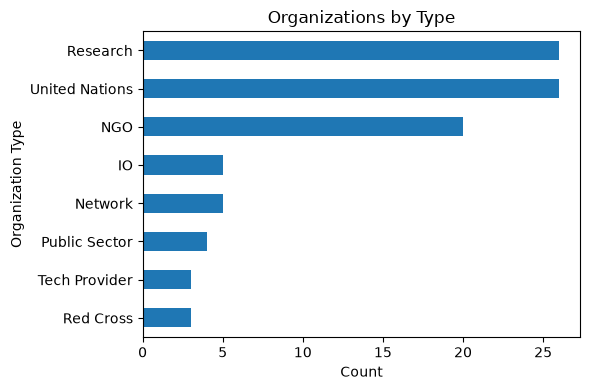

Organization Type
Research          26
United Nations    26
NGO               20
IO                 5
Network            5
Public Sector      4
Tech Provider      3
Red Cross          3
Name: count, dtype: int64

In [4]:
org_type_counts = orgs["Organization Type"].value_counts()
org_type_counts.plot(kind="barh", title="Organizations by Type", figsize=(6, 4))
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
org_type_counts

## 2. Assets overview

In [5]:
assets.head()

,Asset Name,Organization Name,Asset Types,Supporting Donors,Description,Website
0,Capacity Building,3iSolution,[Human Capital & Know-how],"[European Union, Germany, Non-Governmental Organizations, Switzerland, Unite...","The goal is to empower and equip organizations with the knowledge, skill set...",https://3is.org/capacity-building/
1,Information Management Services,3iSolution,[Human Capital & Know-how],"[European Union, Germany, Non-Governmental Organizations, Switzerland, Unite...","The approach focuses on optimizing data collection, analysis, and disseminat...",https://3is.org/information-management/
2,Monitoring & Evaluation,3iSolution,[Crisis Analytics & Insights],"[European Union, Germany, Non-Governmental Organizations, Switzerland, Unite...",Monitoring and evaluation (M&E) activities are supported as fundamental comp...,https://3is.org/monitoring-evaluation/
3,Strategy & Systems Development,3iSolution,[Human Capital & Know-how],"[European Union, Germany, Non-Governmental Organizations, Switzerland, Unite...",Strategy & Systems Development offers a comprehensive suite of services desi...,https://3is.org/strategy-systems-development/
4,Humanitarian Access Overview,ACAPS,[Data Sets & Commons],"[Canada, European Union, Norway, Switzerland, United Kingdom]",The Global Humanitarian Access Overview is ACAPS’ twice-yearly assessment of...,https://www.acaps.org/en/thematics/all-topics/humanitarian-access


In [6]:
print("Missing values per column:")
print(assets.isna().sum())
print()
print("Assets per organization (top 10):")
print(assets["Organization Name"].value_counts().head(10))

Missing values per column:
Asset Name           0
Organization Name    0
Asset Types          0
Supporting Donors    0
Description          1
Website              5
dtype: int64

Assets per organization (top 10):
Organization Name
UNHCR: United Nations High Commissioner for Refugees       14
WFP: United Nations World Food Programme                   13
IOM: International Organization for Migration              11
SIPRI: Stockholm International Peace Research Institute     7
UNICEF: United Nations Children's Fund                      7
World Bank Group                                            7
GEM: Global Earthquake Model Foundation                     6
WHO: World Health Organization                              6
ACLED: Armed Conflict Location & Event Data                 5
IDMC: Internal Displacement Monitoring Centre               5
Name: count, dtype: int64


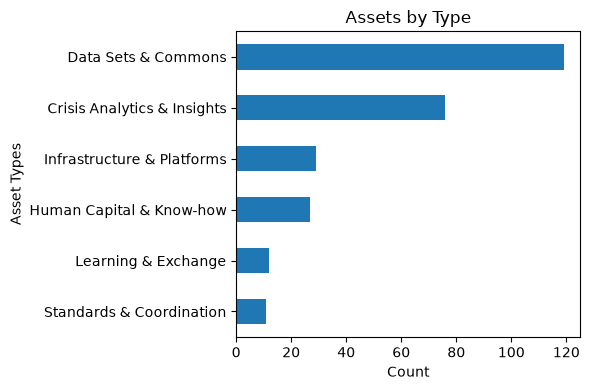

Asset Types
Data Sets & Commons            119
Crisis Analytics & Insights     76
Infrastructure & Platforms      29
Human Capital & Know-how        27
Learning & Exchange             12
Standards & Coordination        11
Name: count, dtype: int64

In [7]:
asset_type_counts = assets["Asset Types"].explode().value_counts()
asset_type_counts.plot(kind="barh", title="Assets by Type", figsize=(6, 4))
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
asset_type_counts

## 3. Donor analysis

Which donors appear most frequently, at both the organization and asset level. Note some
entries are donor *categories* (e.g. `European Union`, `Non-Governmental Organizations`)
rather than individual countries.

Unique donor labels (organizations): 76


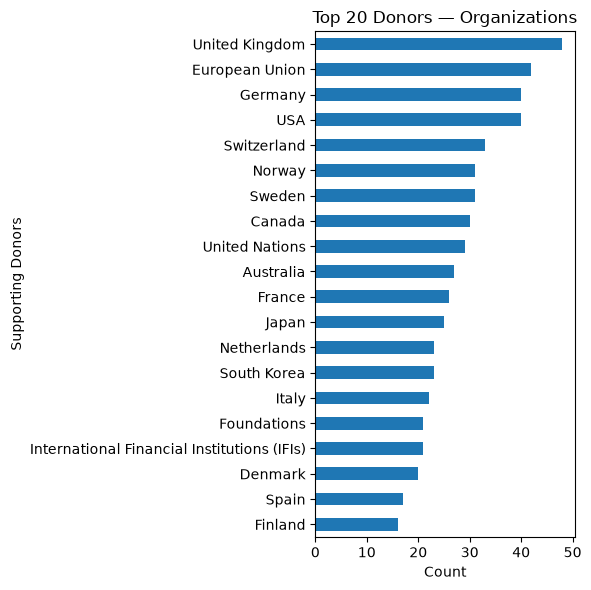

In [8]:
org_donor_counts = orgs["Supporting Donors"].explode().value_counts()
print(f"Unique donor labels (organizations): {org_donor_counts.shape[0]}")
org_donor_counts.head(20).plot(kind="barh", title="Top 20 Donors — Organizations", figsize=(6, 6))
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Unique donor labels (assets): 68


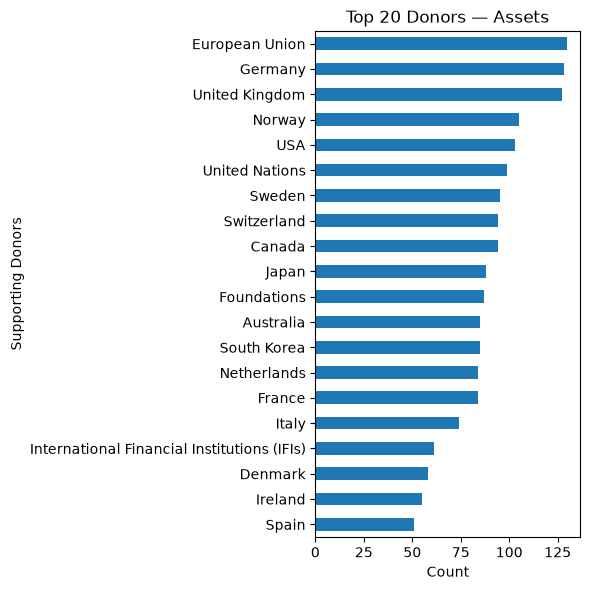

In [9]:
asset_donor_counts = assets["Supporting Donors"].explode().value_counts()
print(f"Unique donor labels (assets): {asset_donor_counts.shape[0]}")
asset_donor_counts.head(20).plot(kind="barh", title="Top 20 Donors — Assets", figsize=(6, 6))
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Organization–asset relationship

How many assets does each organization type produce, and how does asset type mix vary
by organization type? Note: some assets list multiple organizations (`;`-joined in the
raw `Organization Name` field), so a direct merge may need care — check for this first.

In [10]:
multi_org_assets = assets[assets["Organization Name"].str.contains(";", na=False)]
print(f"Assets with multiple listed organizations: {len(multi_org_assets)}")
multi_org_assets[["Asset Name", "Organization Name"]].head(10)

Assets with multiple listed organizations: 23


,Asset Name,Organization Name
5,INFORM Severity,ACAPS; INFORM Consortium
20,PeaceRep,Coventry University; LSE: London School of Economics and Political Science; ...
32,Epidemic Intelligence from Open Sources (EIOS),EC JRC: Joint Research Centre; WHO: World Health Organization
33,Global Disaster Alert and Coordination System (GDACS),EC JRC: Joint Research Centre; OCHA: United Nations Office for the Coordinat...
35,INFORM Climate Change,EC JRC: Joint Research Centre; INFORM Consortium
36,INFORM Risk,EC JRC: Joint Research Centre; INFORM Consortium
43,Food Prices Data,FAO: Food and Agriculture Organization of the United Nations ; WFP: United N...
44,Food Security and Nutrition Update,FAO: Food and Agriculture Organization of the United Nations ; FSNWG: Food S...
53,GRID3: Geo-Referenced Infrastructure and Demographic Data for Development,Flowminder Foundation; UNFPA: United Nations Population Fund; WorldPop
81,Missing Maps,HOT: Humanitarian Open Street Map Team; MapSwipe; Netherlands Red Cross


In [11]:
# explode multi-organization assets so each (asset, org) pair is one row
assets_exploded = assets.copy()
assets_exploded["Organization Name"] = assets_exploded["Organization Name"].str.split(";")
assets_exploded = assets_exploded.explode("Organization Name")
assets_exploded["Organization Name"] = assets_exploded["Organization Name"].str.strip()

merged = assets_exploded.merge(
    orgs[["Organization Name", "Organization Type"]], on="Organization Name", how="left"
)
print("Assets that couldn't be matched to a known organization:")
print(merged[merged["Organization Type"].isna()]["Organization Name"].unique())

Assets that couldn't be matched to a known organization:
<StringArray>
[                                          'WHO: World Health Organization',
             'FAO: Food and Agriculture Organization of the United Nations',
                                       'FHN: Feminist Humanitarian Network',
                                                  'Pacific Disaster Center',
 'UNDPPA: United Nations Department of Political and Peacebuilding Affairs',
                               'UNEP: United Nations Environment Programme',
                                                         'World Bank Group',
                                               'USGS: US Geological Survey',
                                   'WMO: World Meteorological Organization',
                'World Bank-UNHCR Joint Data Center on Forced Displacement',
                                          'WPDx: Water Point Data Exchange']
Length: 11, dtype: str


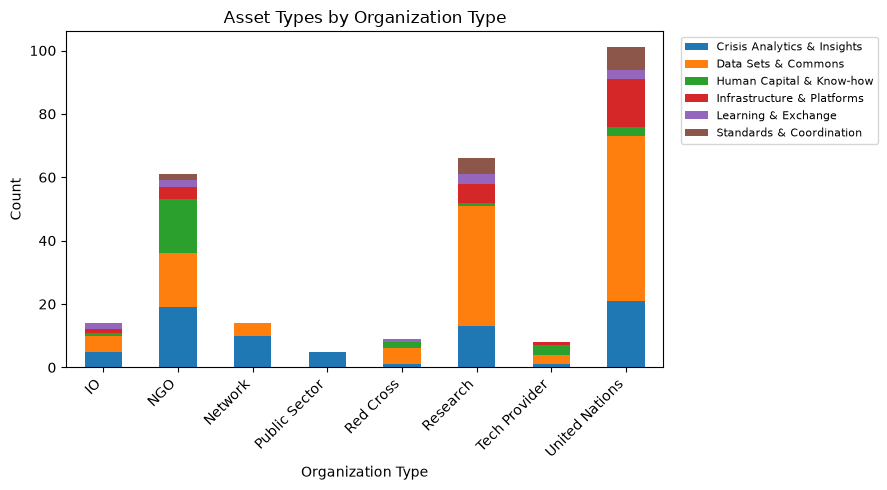

Asset Types,Crisis Analytics & Insights,Data Sets & Commons,Human Capital & Know-how,Infrastructure & Platforms,Learning & Exchange,Standards & Coordination
Organization Type,,,,,,
IO,5,5,1,1,2,0
NGO,19,17,17,4,2,2
Network,10,4,0,0,0,0
Public Sector,5,0,0,0,0,0
Red Cross,1,5,2,0,1,0
Research,13,38,1,6,3,5
Tech Provider,1,3,3,1,0,0
United Nations,21,52,3,15,3,7


In [12]:
pivot = (
    merged.explode("Asset Types")
    .groupby(["Organization Type", "Asset Types"])
    .size()
    .unstack(fill_value=0)
)
pivot.plot(kind="bar", stacked=True, figsize=(9, 5), title="Asset Types by Organization Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
pivot

## 5. Next steps

- Normalize donor category labels vs. individual countries (e.g. treat `European Union`
  as a donor entity, not a country) if a country-level analysis is needed.
- Investigate the unmatched organization names above (typos/aliases between the two
  files) before building a combined org-asset graph.
- Consider a bipartite network (organizations x donors, or organizations x asset types)
  for the ecosystem-mapping analysis referenced in `paper/`.

## 6. Donor dependency analysis

Since the data only records donor *presence* (not funding amounts), dependency is
proxied structurally:

- **Donor count per organization** — fewer donors implies higher concentration risk.
- **Single-donor organizations** — orgs with exactly one listed donor (highest risk).
- **Donor criticality** — for each donor, how many organizations rely on it as their
  *sole* supporter. This flags donors that would leave orgs with zero funding sources
  if they exited (a simple single-point-of-failure proxy), as distinct from donors that
  simply fund many organizations (breadth) but where others share the load.

In [13]:
org_donor_n = orgs["Supporting Donors"].apply(len)
print("Donor count per organization — summary:")
print(org_donor_n.describe())

single_donor_orgs = orgs[org_donor_n == 1][["Organization Name", "Organization Type", "Supporting Donors"]]
print(f"\nOrganizations with a single donor ({len(single_donor_orgs)} of {len(orgs)}):")
single_donor_orgs

Donor count per organization — summary:
count    92.000000
mean      8.597826
std      10.207797
min       0.000000
25%       1.000000
50%       4.000000
75%      11.250000
max      31.000000
Name: Supporting Donors, dtype: float64

Organizations with a single donor (26 of 92):


,Organization Name,Organization Type,Supporting Donors
2,ACLED: Armed Conflict Location & Event Data,NGO,[CRAF’d]
4,Arab Barometer,Research,[USA]
7,Coventry University,Research,[United Kingdom]
9,Data2x,NGO,[Foundations]
11,DFS: Data Friendly Space,Tech Provider,[Non-Governmental Organizations]
15,EC JRC: Joint Research Centre,Public Sector,[European Union]
16,ECMWF: European Centre for Medium-Range Weather Forecasts,IO,[European Union]
19,FEWS NET: Famine Early Warning Systems Network,Public Sector,[USA]
29,HIIK: Heidelberg Institute for International Conflict Research,Research,[Germany]
30,HOT: Humanitarian Open Street Map Team,NGO,[Foundations]


In [14]:
import networkx as nx

# bipartite org-donor graph: edge = donor supports org
B = nx.Graph()
for _, row in orgs.iterrows():
    org_node = ("org", row["Organization Name"])
    B.add_node(org_node, bipartite="org")
    for donor in row["Supporting Donors"]:
        donor_node = ("donor", donor)
        B.add_node(donor_node, bipartite="donor")
        B.add_edge(org_node, donor_node)

donor_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "donor"]
org_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "org"]
print(f"Bipartite graph: {len(org_nodes)} orgs, {len(donor_nodes)} donors, {B.number_of_edges()} edges")

# criticality: for each donor, count orgs where it is the sole supporter
criticality = {donor: 0 for donor in donor_nodes}
for org_node in org_nodes:
    neighbors = list(B.neighbors(org_node))
    if len(neighbors) == 1:
        criticality[neighbors[0]] += 1

donor_stats = pd.DataFrame(
    {
        "donor": [d[1] for d in donor_nodes],
        "orgs_funded": [B.degree(d) for d in donor_nodes],
        "sole_supporter_count": [criticality[d] for d in donor_nodes],
    }
).sort_values("sole_supporter_count", ascending=False)

print("\nDonors ranked by criticality (# orgs solely dependent on them):")
donor_stats.head(15)

Bipartite graph: 92 orgs, 76 donors, 791 edges

Donors ranked by criticality (# orgs solely dependent on them):


,donor,orgs_funded,sole_supporter_count
12,USA,40,8
7,United Kingdom,48,7
9,Foundations,21,2
0,European Union,42,2
11,Sweden,31,1
2,Non-Governmental Organizations,6,1
8,CRAF’d,7,1
10,Netherlands,23,1
14,International Financial Institutions (IFIs),21,1
31,Italy,22,1


**Reading these results:** `orgs_funded` measures a donor's breadth (how many orgs it
touches); `sole_supporter_count` measures criticality (how many orgs would lose *all*
funding if that donor exited). USA and UK are both broad *and* critical — worth flagging
in the paper as concentration risk. Remember `Supporting Donors` mixes individual
countries with categories (`Foundations`, `Non-Governmental Organizations`, `European
Union`), so cross-check whether category labels should be treated differently from
countries before drawing policy conclusions.